# Importing python libraries to be used 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
#setting the size of figures to be displayed in the notebook
sns.set_theme(rc={"figure.figsize": (12, 6)})

# Loading datasets to be used
Add more datasets as needed

In [56]:
# Loading TFT datasets
TFT_C_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_Challenger_MatchData.csv")
TFT_D_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_Diamond_MatchData.csv")
TFT_GM_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_GrandMaster_MatchData.csv")
TFT_M_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_Master_MatchData.csv")
TFT_P_Data_df = pd.read_csv("Datasets\TFT_Match_Data\TFT_Platinum_MatchData.csv")

In [3]:
# Loading PUBG datasets 
PUBG_death1_df = pd.read_csv("Datasets\\PUBG_Match_Data\\deaths\\kill_match_stats_final_0.csv")
PUBG_death2_df = pd.read_csv("Datasets\\PUBG_Match_Data\\deaths\\kill_match_stats_final_1.csv")
PUBG_death3_df = pd.read_csv("Datasets\\PUBG_Match_Data\\deaths\\kill_match_stats_final_2.csv")
PUBG_death4_df = pd.read_csv("Datasets\\PUBG_Match_Data\\deaths\\kill_match_stats_final_3.csv")
PUBG_death5_df = pd.read_csv("Datasets\\PUBG_Match_Data\\deaths\\kill_match_stats_final_4.csv")
PUBG_agg_stats_df = pd.read_csv("Datasets\\PUBG_Match_Data\\aggregate\\agg_match_stats_4.csv")

In [ ]:
# Loading CSGO datasets
CSGO_M_DMG1_df = pd.read_csv("Datasets\CSGO_Match_Data\esea_master_dmg_demos.part1.csv")
CSGO_M_DMG2_df = pd.read_csv("Datasets\CSGO_Match_Data\esea_master_dmg_demos.part2.csv")
CSGO_M_GRE1_df = pd.read_csv("Datasets\CSGO_Match_Data\esea_master_grenades_demos.part1.csv")
CSGO_M_GRE2_df = pd.read_csv("Datasets\CSGO_Match_Data\esea_master_grenades_demos.part2.csv")
CSGO_M_Kills1_df = pd.read_csv("Datasets\CSGO_Match_Data\esea_master_kills_demos.part1.csv")
CSGO_M_Kills2_df = pd.read_csv("Datasets\CSGO_Match_Data\esea_master_kills_demos.part2.csv")
CSGO_Meta_1_df = pd.read_csv("Datasets\CSGO_Match_Data\esea_meta_demos.part1.csv")
CSGO_Meta_2_df = pd.read_csv("Datasets\CSGO_Match_Data\esea_meta_demos.part2.csv")
CSGO_Map_df = pd.read_csv("Datasets\CSGO_Match_Data\map_data.csv")
CSGO_MM_Grenades = pd.read_csv("Datasets\CSGO_Match_Data\mm_grenades_demos.csv")
CSGO_MM_Master = pd.read_csv("Datasets\CSGO_Match_Data\mm_master_demos.csv")


KeyboardInterrupt



# Data Preprocessing for TFT


In [61]:
TFT_C_Processed = TFT_C_Data_df.drop(columns=['gameId','gameDuration'])
TFT_D_Processed = TFT_D_Data_df.drop(columns=['gameId','gameDuration'])
TFT_GM_Processed = TFT_GM_Data_df.drop(columns=['gameId','gameDuration'])
TFT_M_Processed = TFT_M_Data_df.drop(columns=['gameId','gameDuration'])
TFT_P_Processed = TFT_P_Data_df.drop(columns=['gameId','gameDuration'])


In [ ]:
#convert to minutes

TFT_C_Processed['ingameDuration'] = TFT_C_Processed['ingameDuration'] / 60
TFT_C_Processed['ingameDuration'] = np.round(TFT_C_Processed['ingameDuration'], decimals=2)

TFT_D_Processed['ingameDuration'] = TFT_D_Processed['ingameDuration'] / 60
TFT_D_Processed['ingameDuration'] = np.round(TFT_D_Processed['ingameDuration'], decimals=2)

TFT_GM_Processed['ingameDuration'] = TFT_GM_Processed['ingameDuration'] / 60
TFT_GM_Processed['ingameDuration'] = np.round(TFT_GM_Processed['ingameDuration'], decimals=2)

TFT_M_Processed['ingameDuration'] = TFT_M_Processed['ingameDuration'] / 60
TFT_M_Processed['ingameDuration'] = np.round(TFT_M_Processed['ingameDuration'], decimals=2)

TFT_P_Processed['ingameDuration'] = TFT_P_Processed['ingameDuration'] / 60
TFT_P_Processed['ingameDuration'] = np.round(TFT_P_Processed['ingameDuration'], decimals=2)



,level,lastRound,Ranked,ingameDuration,combination,champion
0,8,37,4,34.83,"{'DarkStar': 2, 'Protector': 4, 'Rebel': 2, 'S...","{'JarvanIV': {'items': [2, 58], 'star': 3}, 'S..."
1,7,26,7,24.47,"{'Chrono': 1, 'Cybernetic': 1, 'Infiltrator': ...","{'Malphite': {'items': [], 'star': 3}, 'KhaZix..."
2,7,26,8,24.41,"{'DarkStar': 1, 'Protector': 1, 'Set3_Mystic':...","{'Poppy': {'items': [25, 27], 'star': 3}, 'Zoe..."
3,8,35,5,33.47,"{'Chrono': 2, 'Cybernetic': 1, 'Infiltrator': ...","{'TwistedFate': {'items': [], 'star': 3}, 'Mal..."
4,7,41,2,38.63,"{'DarkStar': 1, 'Demolitionist': 2, 'Infiltrat...","{'KhaZix': {'items': [], 'star': 2}, 'KaiSa': ..."


# Data Preprocessing for PUBG

## Preprocessing aggregate match data

As a disclaimer, the PUBG dataset we are using gives the statistics for organizes its data into chunks of 5 categorized as the death statistics and the aggregate statistics. For the aggregate statistics 4 of the csv files exceeded the Git LFS file size limit Github allowed hence why only a size csv file is being used for exploring aggregate data. 

Aggregation data for PUBG matches includes match metadata such as teamIDs, team rankings, kills, survival time, etc. The baseline metric we will be using to measure success is a team's placement at the end of a match.

Beginning preprocessing we drop all rows containing null values as well as columns that we won't be needing for analysis. 

In [94]:
PUBG_agg_stats_df = PUBG_agg_stats_df.dropna()
PUBG_agg_stats_df = PUBG_agg_stats_df.drop(columns=['date','game_size','match_id','match_mode','team_id','player_name'])

Next we convert the "player_survive_time" column to be measured in minutes rather than seconds.

In [95]:
PUBG_agg_stats_df['player_survive_time'] = PUBG_agg_stats_df['player_survive_time']/60
PUBG_agg_stats_df['player_survive_time'] = np.round(PUBG_agg_stats_df['player_survive_time'], decimals=2)

While this was discovered during EDA, retroactively, we shall put this step before it. There are several extremely high outlier values within the "player_survive_time" column. We attributed these values as encoding errors as they are statistically impossible.

In [96]:
print(PUBG_agg_stats_df['player_survive_time'].sort_values(ascending=False).head(10))

8912398     1.060804e+09
8912396     1.060804e+09
8912397     1.060804e+09
10549657    1.060780e+09
10549703    1.060780e+09
10549701    1.060780e+09
10549706    1.060780e+09
10549725    1.060780e+09
10549720    1.060780e+09
10549694    1.060780e+09
Name: player_survive_time, dtype: float64


To address we decided to drop these rows entirely based on the 99th percentile value

In [97]:
max = PUBG_agg_stats_df['player_survive_time'].quantile(0.99) #this returns 32.24 minutes which is a reasonable number as the average PUBG match does last around 20-30 minutes
PUBG_agg_stats_df = PUBG_agg_stats_df[PUBG_agg_stats_df['player_survive_time'] < max]

## Preprocessing death match data
Since the death match data is split across 5 csv files our first step in preprocessing is combining all the dataframes into one big dataframe. All the files are formatted the exact same so we can use the pandas concat function to quickly stack them ontop of each other.

In [4]:
PUBG_death_df = pd.concat([PUBG_death1_df,PUBG_death2_df,PUBG_death3_df,PUBG_death4_df,PUBG_death5_df])

Next we proceed by dropping rows that contain empty values which are quite numerous since players dying via in game mechanics like drowning or being outside the safe zone leave columns 2-5 empty as there is no player data to encode as the killer. We then also drop other columns we don't need such as match metadata and player names.

In [5]:
PUBG_death_df = PUBG_death_df.dropna()
PUBG_death_df = PUBG_death_df.drop(columns=['killer_name','map','match_id','victim_name','victim_placement'])

Next we create a new column that calculates the distance between a killer and their victim. We can use the euclidean distance formula since we are given x and y coordinates.

In [6]:
dist = np.round(np.sqrt((PUBG_death_df['killer_position_x'] - PUBG_death_df['victim_position_x'])**2 + 
                        (PUBG_death_df['killer_position_y'] - PUBG_death_df['victim_position_y'])**2), 
                        decimals=2)

Before proceeding we first inspect the data within the new column and see that some kills that are encoded are seemingly impossible as they span farther than the actual map's length which is 800,000cm or 8km. When appending this series into the main dataframe we can see these kills are impossible, take for example killing someone with a punch over 8km away. Whether these are hackers, encoding errors, or the game misattributing a kill to the wrong player, these data points are unusable.

In [7]:
PUBG_death_df['kill_distance'] = dist

PUBG_death_df[PUBG_death_df['kill_distance'] > 800000][
    ['killed_by','killer_position_x', 'killer_position_y', 'victim_position_x', 'victim_position_y','kill_distance']
].head(15)

,killed_by,killer_position_x,killer_position_y,victim_position_x,victim_position_y,kill_distance
5,Punch,721944.4,359575.3,0.0,0.0,806534.63
15,Punch,725042.3,361510.1,0.0,0.0,810170.28
53,Punch,725012.6,361189.7,0.0,0.0,810000.78
396,M416,423640.8,712687.2,0.0,0.0,829092.62
453,M416,423694.8,712692.4,0.0,0.0,829124.68
2414,Punch,571319.7,630848.8,0.0,0.0,851103.05
3506,P1911,598558.3,582883.3,0.0,0.0,835478.89
4066,Punch,581497.3,615052.4,0.0,0.0,846421.03
4082,Punch,579321.6,613074.4,0.0,0.0,843489.03
4089,Punch,580189.4,615772.3,0.0,0.0,846046.85


A lot of these outliers occur when either the victim or killer is positioned exactly at (0,0) therefore we will be removing all entries that contain those exact coordinates for either the killer or victim positions.

In [ ]:
PUBG_death_df = PUBG_death_df.query('killer_position_x != 0 and killer_position_y != 0 or victim_position_x != 0 and victim_position_y != 0')

# Exploratory Data Analysis for PUBG 

## Exploratory Data Analysis for aggregate match data

<Axes: xlabel='party_size', ylabel='player_survive_time'>

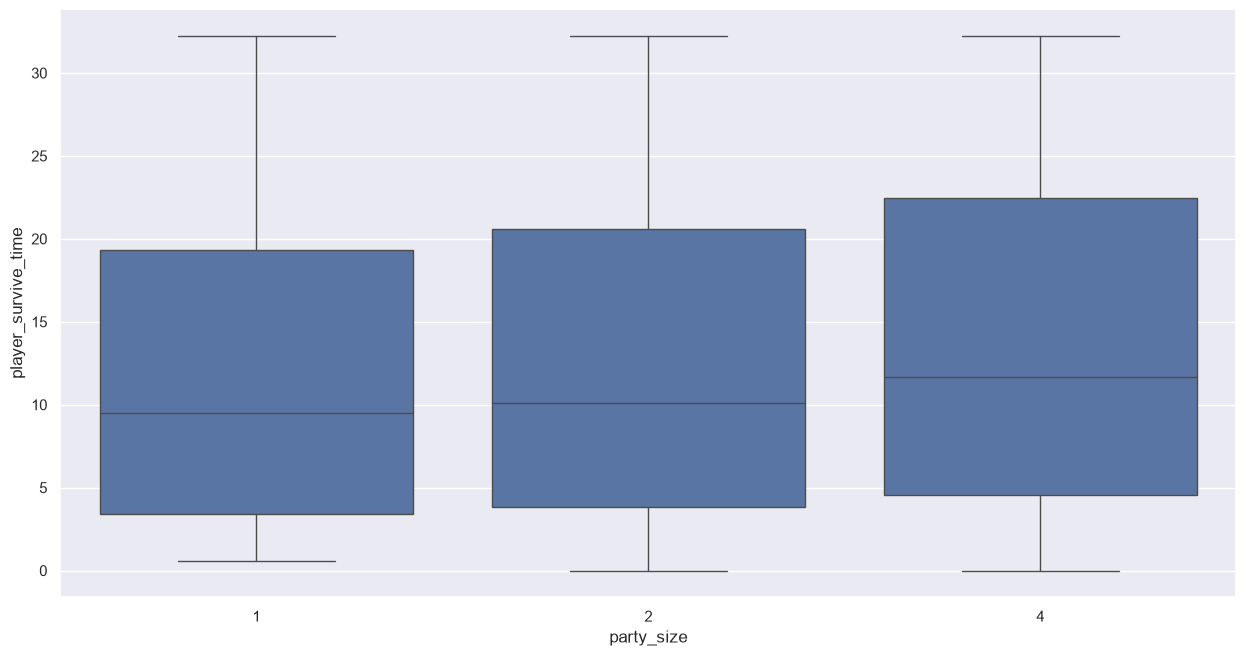

In [111]:
sns.boxplot(data=PUBG_agg_stats_df, x='party_size', y='player_survive_time')

<Axes: xlabel='party_size', ylabel='team_placement'>

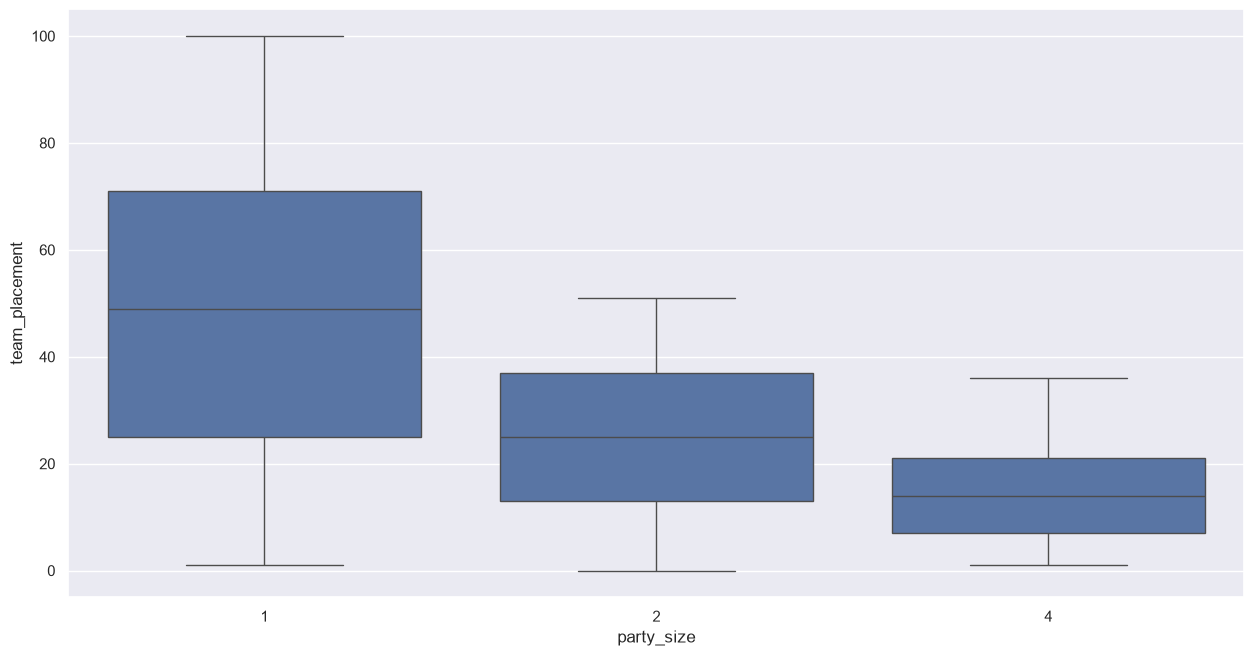

In [112]:
sns.boxplot(data=PUBG_agg_stats_df, x='party_size', y='team_placement')

<Axes: xlabel='team_placement', ylabel='party_size'>

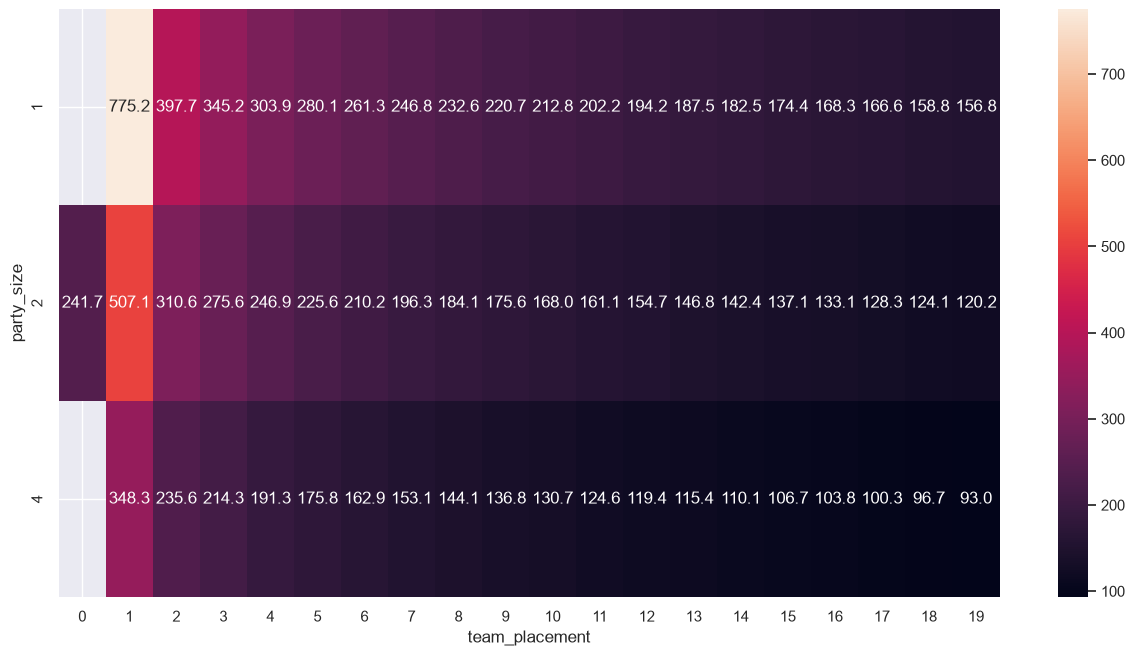

In [110]:
top = PUBG_agg_stats_df[PUBG_agg_stats_df['team_placement'] < 20]
heat = top.pivot_table(index='party_size',columns='team_placement',values='player_dmg',aggfunc='mean')

sns.heatmap(heat, annot=True, fmt='.01f')

<Axes: xlabel='team_placement', ylabel='party_size'>

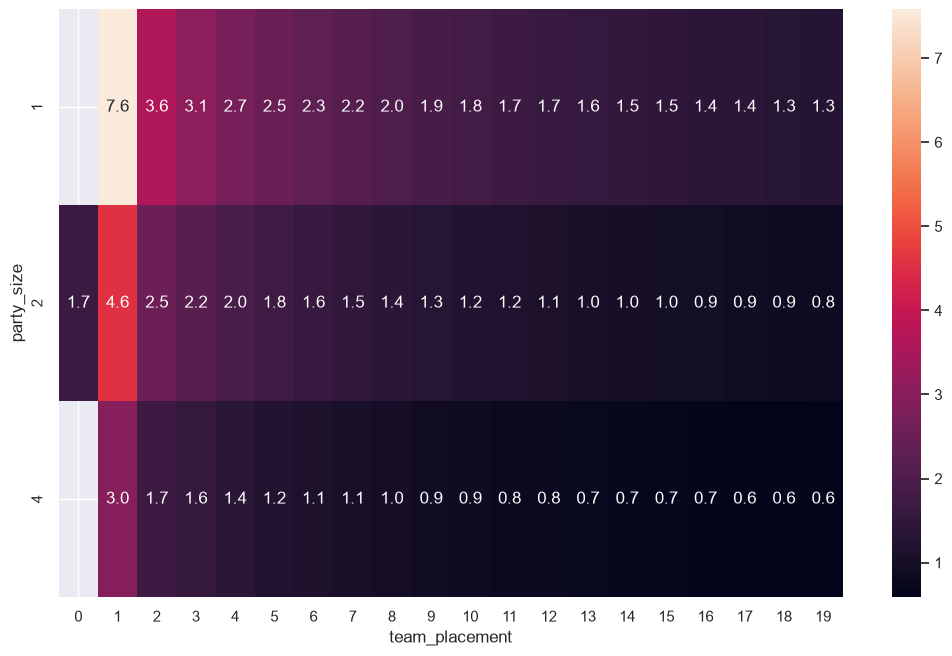

In [108]:
top = PUBG_agg_stats_df[PUBG_agg_stats_df['team_placement'] < 20]
heat = top.pivot_table(index='party_size',columns='team_placement',values='player_kills',aggfunc='mean')

sns.heatmap(heat, annot=True, fmt='.01f')

## Exploratory Data Analysis for death match data

In [18]:
top10 = PUBG_death_df['killed_by'].value_counts().nlargest(10).index

filtered10 = PUBG_death_df[PUBG_death_df['killed_by'].isin(top10)]

sns.displot(filtered10 , x='killed_by', order=top10)

MemoryError: Unable to allocate 349. MiB for an array with shape (45771976, 1) and data type object

# Data Preprocessing for CSGO

In [ ]:
# View dataset info
CSGO_M_DMG1_df.head()


,file,round,tick,seconds,att_team,vic_team,att_side,vic_side,hp_dmg,arm_dmg,...,wp,wp_type,att_id,att_rank,vic_id,vic_rank,att_pos_x,att_pos_y,vic_pos_x,vic_pos_y
0,esea_match_13770997.dem,1,14372,111.8476,World,Animal Style,NaN,CounterTerrorist,1,0,...,Unknown,Unkown,0,0,76561198055054795,0,0.0000,0.00000,0.0000,0.000000
1,esea_match_13770997.dem,1,15972,124.3761,Animal Style,Hentai Hooligans,CounterTerrorist,Terrorist,18,9,...,USP,Pistol,76561198048742997,0,76561198082200410,0,-1499.6900,63.33829,-669.5558,-79.769570
2,esea_match_13770997.dem,1,16058,125.0495,Animal Style,Hentai Hooligans,CounterTerrorist,Terrorist,100,0,...,USP,Pistol,76561198055054795,0,76561197961009213,0,-1066.8740,3.44563,-614.1868,-91.707770
3,esea_match_13770997.dem,1,16066,125.1121,Hentai Hooligans,Animal Style,Terrorist,CounterTerrorist,12,7,...,Glock,Pistol,76561198082200410,0,76561198055054795,0,-747.3146,-49.32681,-1065.5560,9.381622
4,esea_match_13770997.dem,1,16108,125.4410,Animal Style,Hentai Hooligans,CounterTerrorist,Terrorist,15,7,...,USP,Pistol,76561198048742997,0,76561198082200410,0,-1501.8610,49.19798,-748.4188,-53.469220


In [49]:
# Check for any null values in the data
CSGO_M_DMG1_df.isnull().any()

file               False
round              False
tick               False
seconds             True
att_team           False
vic_team           False
att_side            True
vic_side           False
hp_dmg             False
arm_dmg            False
is_bomb_planted    False
bomb_site           True
hitbox             False
wp                 False
wp_type            False
att_id             False
att_rank           False
vic_id             False
vic_rank           False
att_pos_x          False
att_pos_y          False
vic_pos_x          False
vic_pos_y          False
dtype: bool

As shown here, att_side, seconds and bomb_site have null values

In [50]:
# Looking at the dataset, att_side and vic_side should have Terrorist and CounterTerrorist in both columns. So, we can do categorical imputation with a function to classify them.
# Imputation for att_side
def impute_att_side(cols):
    att_side = cols[0]
    vic_side = cols[1]
    if pd.isnull(att_side):
       if vic_side == 'CounterTerrorist':
           return 'Terrorist'
       else:
           return 'CounterTerrorist'
    else:
        return att_side

CSGO_M_DMG1_df["att_side"] = CSGO_M_DMG1_df.loc[:, ["att_side", "vic_side"]].apply(impute_att_side, axis = 1)


C:\Users\Perez\AppData\Local\Temp\ipykernel_29992\3502958027.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  att_side = cols[0]
C:\Users\Perez\AppData\Local\Temp\ipykernel_29992\3502958027.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  vic_side = cols[1]


In [53]:
CSGO_M_DMG1_df.isnull().sum()

file                     0
round                    0
tick                     0
seconds                515
att_team                 0
vic_team                 0
att_side                 0
vic_side                 0
hp_dmg                   0
arm_dmg                  0
is_bomb_planted          0
bomb_site          5129343
hitbox                   0
wp                       0
wp_type                  0
att_id                   0
att_rank                 0
vic_id                   0
vic_rank                 0
att_pos_x                0
att_pos_y                0
vic_pos_x                0
vic_pos_y                0
dtype: int64

In [56]:
# We decide to drop the null values for seconds as it is very small in comparison with the total observations listed here
CSGO_M_DMG1_df = CSGO_M_DMG1_df.dropna(subset="seconds")
CSGO_M_DMG1_df.isnull().sum()

file                     0
round                    0
tick                     0
seconds                  0
att_team                 0
vic_team                 0
att_side                 0
vic_side                 0
hp_dmg                   0
arm_dmg                  0
is_bomb_planted          0
bomb_site          5128875
hitbox                   0
wp                       0
wp_type                  0
att_id                   0
att_rank                 0
vic_id                   0
vic_rank                 0
att_pos_x                0
att_pos_y                0
vic_pos_x                0
vic_pos_y                0
dtype: int64

In [57]:
# However for the bomb site, we drop the column since it has a lot of missing values
CSGO_M_DMG1_df.drop('bomb_site', axis = 1, inplace = True)
CSGO_M_DMG1_df.isnull().sum()

file               0
round              0
tick               0
seconds            0
att_team           0
vic_team           0
att_side           0
vic_side           0
hp_dmg             0
arm_dmg            0
is_bomb_planted    0
hitbox             0
wp                 0
wp_type            0
att_id             0
att_rank           0
vic_id             0
vic_rank           0
att_pos_x          0
att_pos_y          0
vic_pos_x          0
vic_pos_y          0
dtype: int64

In [ ]:
CSGO_M_DMG2_df.head(20)

,file,round,tick,seconds,att_team,vic_team,att_side,vic_side,hp_dmg,arm_dmg,...,wp,wp_type,att_id,att_rank,vic_id,vic_rank,att_pos_x,att_pos_y,vic_pos_x,vic_pos_y
0,esea_match_13818366.dem,1,21257,165.8779,Team 2,Team 1,Terrorist,CounterTerrorist,20,0,...,Glock,Pistol,76561198242409332,0,76561198323654039,0,695.9623,1459.5790,-299.9824,2220.1480
1,esea_match_13818366.dem,1,21653,168.9752,Team 1,Team 2,CounterTerrorist,Terrorist,100,0,...,USP,Pistol,76561198013283167,0,76561198355844440,0,-236.3433,923.7209,271.5201,2097.4790
2,esea_match_13818366.dem,1,21717,169.4758,Team 1,Team 2,CounterTerrorist,Terrorist,100,0,...,USP,Pistol,76561198323654039,0,76561198305399476,0,-422.4744,2051.0920,909.0534,1543.7200
3,esea_match_13818366.dem,1,21937,171.1965,Team 1,Team 2,CounterTerrorist,Terrorist,14,6,...,USP,Pistol,76561198323654039,0,76561197962070685,0,-263.6333,2248.5440,704.7518,1579.3470
4,esea_match_13818366.dem,1,22229,173.4804,Team 1,Team 2,CounterTerrorist,Terrorist,100,0,...,USP,Pistol,76561198853893462,0,76561198397252030,0,-558.0109,-874.1711,254.4920,-691.1022
5,esea_match_13818366.dem,1,22565,176.1084,Team 1,Team 2,CounterTerrorist,Terrorist,14,7,...,USP,Pistol,76561198323654039,0,76561197962070685,0,-257.3235,2237.7820,565.4832,1591.9950
6,esea_match_13818366.dem,1,22653,176.7967,Team 2,Team 1,Terrorist,CounterTerrorist,8,4,...,Glock,Pistol,76561198242409332,0,76561198186753298,0,721.1249,1737.9440,-683.3134,1264.1540
7,esea_match_13818366.dem,1,22711,177.2503,Team 2,Team 1,Terrorist,CounterTerrorist,8,4,...,Glock,Pistol,76561198242409332,0,76561198186753298,0,694.5822,1815.2100,-685.8182,1271.3080
8,esea_match_13818366.dem,1,22807,178.0012,Team 1,Team 2,CounterTerrorist,Terrorist,13,6,...,USP,Pistol,76561198186753298,0,76561198242409332,0,-681.6322,1259.1700,672.0367,1854.8990
9,esea_match_13818366.dem,1,24575,191.8296,Team 1,Team 2,CounterTerrorist,Terrorist,2,1,...,USP,Pistol,76561198323654039,0,76561198242409332,0,212.5068,1298.0160,554.1100,1945.2070


In [64]:
CSGO_M_DMG2_df.isnull().any()

file               False
round              False
tick               False
seconds             True
att_team           False
vic_team           False
att_side            True
vic_side           False
hp_dmg             False
arm_dmg            False
is_bomb_planted    False
bomb_site           True
hitbox             False
wp                 False
wp_type            False
att_id             False
att_rank           False
vic_id             False
vic_rank           False
att_pos_x          False
att_pos_y          False
vic_pos_x          False
vic_pos_y          False
dtype: bool

In [65]:
def impute_att_side(cols):
    att_side = cols[0]
    vic_side = cols[1]
    if pd.isnull(att_side):
       if vic_side == 'CounterTerrorist':
           return 'Terrorist'
       else:
           return 'CounterTerrorist'
    else:
        return att_side

CSGO_M_DMG2_df["att_side"] = CSGO_M_DMG2_df.loc[:, ["att_side", "vic_side"]].apply(impute_att_side, axis = 1)
CSGO_M_DMG2_df.isnull().any()

C:\Users\Perez\AppData\Local\Temp\ipykernel_29992\855319145.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  att_side = cols[0]
C:\Users\Perez\AppData\Local\Temp\ipykernel_29992\855319145.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  vic_side = cols[1]


file               False
round              False
tick               False
seconds             True
att_team           False
vic_team           False
att_side           False
vic_side           False
hp_dmg             False
arm_dmg            False
is_bomb_planted    False
bomb_site           True
hitbox             False
wp                 False
wp_type            False
att_id             False
att_rank           False
vic_id             False
vic_rank           False
att_pos_x          False
att_pos_y          False
vic_pos_x          False
vic_pos_y          False
dtype: bool

In [66]:
CSGO_M_DMG2_df = CSGO_M_DMG2_df.dropna(subset="seconds")
CSGO_M_DMG2_df.isnull().sum()

file                     0
round                    0
tick                     0
seconds                  0
att_team                 0
vic_team                 0
att_side                 0
vic_side                 0
hp_dmg                   0
arm_dmg                  0
is_bomb_planted          0
bomb_site          3888851
hitbox                   0
wp                       0
wp_type                  0
att_id                   0
att_rank                 0
vic_id                   0
vic_rank                 0
att_pos_x                0
att_pos_y                0
vic_pos_x                0
vic_pos_y                0
dtype: int64

In [67]:
CSGO_M_DMG2_df.drop('bomb_site', axis = 1, inplace = True)
CSGO_M_DMG2_df.isnull().sum()

file               0
round              0
tick               0
seconds            0
att_team           0
vic_team           0
att_side           0
vic_side           0
hp_dmg             0
arm_dmg            0
is_bomb_planted    0
hitbox             0
wp                 0
wp_type            0
att_id             0
att_rank           0
vic_id             0
vic_rank           0
att_pos_x          0
att_pos_y          0
vic_pos_x          0
vic_pos_y          0
dtype: int64